# TAREA 1: Análisis de Rendimiento y Paralelización - Conjunto de Mandelbrot

**Asignatura:** Procesamiento Paralelo de Datos - Curso 2025/2026

**Descripción del caso de uso:**

El conjunto de Mandelbrot es un fractal definido en el plano complejo. Para cada punto $c=x+y_i$, iteramos la fórmula $z_{n+1}=z_n^2+c$ partiendo de $z_0=0$. Si tras un número máximo de iteraciones $|z|$ no supera 2, el punto pertenece al conjunto.

Este problema es ideal para análisis de rendimiento y paralelización porque:
- El cómputo es independiente píxel a píxel (embarrassingly parallel).
- Los bucles anidados en Python puro son un cuello de botella claro.
- Se puede dividir la imagen por filas entre procesos de forma natural.
- Existen librerías optimizadas como `NumPy` o `numba` que permiten comparar diferentes enfoques.

**Estructura del notebook:**

1. Paso 0: Implementación secuencial en Python puro.
2. Paso 1: Profiling (cProfile + `line_profiler`)
3. Paso 2: Paralelización con multiprocessing
4. Paso 3: Optimización con librerías especializadas (`NumPy` vectorizado)
5. Paso 4: Actividades opcionales:

   - OP1: Análisis de escalabilidad + Ley de Amdahl
   - OP2: `numba` + `multiprocessing`
   - OP3: Alternativas (`joblib`)
   - OP4: Comparativa visual de todos los enfoques

---

## Paso 0: Implementación Secuencial (Python puro)

Implementamos el cálculo del conjunto de Mandelbrot usando **exclusivamente** bucles y operaciones básicas de Python, sin llamadas a librerías externas (valo para visualización al final). Esto nos dará la línea base (baseline) contra la que mediremos todas las optimizaciones posteriores.

In [1]:
# === IMPORTS BÁSICOS ===
# Solo usamos librerías estándasr para el cómputo.
# matplotlib y numpy se usan SOLO para visualización y guardado, no para el cálculo.
import time
import numpy as np
import matplotlib.pyplot as plt

### 0.1: Parámetros del fractal

Definimos los parámetros que controlan la resolución y el rango del fractal.
- `WIDTH` y `HEIGHT`: resolución de la imagen en píxeles.
- `MAX_ITER`: número máximo de iteraciones por píxel. Más iteraciones = más detalle en los bordes del conjunto, pero más tiempo de cómputo.
- `X_MIN, X_MAX, Y_MIN, Y_MAX`: ventana del plano complejo que vamos a renderizar. Los valores por defecto muestran el conjunto de Mandelbrot completo.

In [2]:
# --- Parámetros de la imagen ---
# Usamos una resolución moderada para que el profiling no tarde demasiado,
# pero lo suficiente para que el tiempo de cómputo sea significativo (~segundos).
WIDTH = 800     # Número de píxeles en el eje horizontal (eje real)
HEIGHT = 600    # Número de píxeles en el eje vertical (eje imaginario)
MAX_ITER = 200  # Máximo de iteraciones antes de declarar que un punto pertenece al conjunto

# --- Ventana del plano complejo ---
# Estos valores encuadran el conjunto de Mandelbrot completo centrado en el origen.
X_MIN = -2.5    # Límite izquierdo del eje real
X_MAX = 1.0     # Límite derecho del eje real
Y_MIN = -1.25   # Límite inferior del eje imaginario
Y_MAX = 1.25    # Límite superior del eje imaginario

### 0.2: Función de cómputo por píxel

La función `mandelbrot_pixel` calcula, para un punto del plano complejo, cuántas iteraciones tarda en "escapar" ($|z|>2$). Si no escapa tras `MAX_ITER` iteraciones, devuelve `MAX_ITER` (pertenece al conjunto).

Esta es la **unidad mínima de trabajo** y será el objetivo principal de la paralelización.

In [3]:
def mandelbrot_pixel(c_real: float, c_imag: float, max_iter: int) -> int:
    """
    Calcula el número de iteraciones para un punto del plano complejo.

    Parámetros:
        c_real: Parte real del número complejo c (coordenada x).
        c_imag: Parte imaginaria del número complejo c (coordenada y).
        max_iter: Número máximo de iteraciones permitidas.

    Retorna:
        Número de iteraciones hasta que |z| > 2, o max_iter si no escapa.

    Nota:
        Usamos la condición z_real² y z_imag² > 4.0 en lugar de sqrt(z_real² + z_imag²) > 2.0
        para evitar la costosa operación de raíz cuadrada en cada iteración.
    """
    # Partimos de z_0 = 0 + 0i
    z_real = 0.0
    z_imag = 0.0

    # Iteramos z_{n+1} = z_n² + c hasta que escape o agotemos iteraciones
    for n in range(max_iter):
        # Calculamos z² = (z_real + z_imag * i)²
        # Parte real de z²: z_real² - z_imag²
        # Parte imaginaria de z²: 2 * z_real * z_imag
        z_real_sq = z_real * z_real     # z_real² (lo guardamos para reutilizar)
        z_imag_sq = z_imag * z_imag     # z_imag² (lo guardamos para reutilizar)

        # Condición de escape: |z|² = z_real² + z_imag² > 4.0
        # (equivalente a |z| > 2.0, pero sin calcular la raíz cuadrada)
        if z_real_sq + z_imag_sq > 4.0:
            return n  # El punto ha escapado en la iteración n

        # Actualizamos z: z_{n+1} = z_n² + c
        z_imag = 2.0 * z_real * z_imag + c_imag     # Primero la parte imaginaria (usa z_real original)
        z_real = z_real_sq - z_imag_sq + c_real     # Luego la parte real

    # Si llegamos aquí, el punto no escapó: pertenece al conjunto
    return max_iter

### 0.3: Función de generación de la imagen completa (secuencial)

Recorremos cada píxel de la imagen, convertimos sus coordenadas (filas, columna) a un punto del plano complejo, y calculamos las iteraciones con `mandelbrot_pixel`.

El resultado es una lista de listas (matriz) donde cada valor representa el número de iteraciones de ese píxel.

In [4]:
def mandelbrot_sequential(
    width: int,
    height: int,
    x_min: float,
    x_max: float,
    y_min: float,
    y_max: float,
    max_iter: int
) -> list[list[int]]:
    """
    Parámetros:
        width, height: Dimensiones de la imagen en píxeles.
        x_min, x_max: Rango del eje real (horizontal) del plano complejo
        y_min, y_max: Rango del eje imaginario (vertical) del plano complejo
        max_iter: Máximo de iteraciones por píxel

    Retorna:
        Matriz height x width con el número de iteraciones de cada píxel
    """
    # Inicializamos la imagen como una lista de listas (Python puro, sin numpy)
    image = []

    # Recorremos cada fila (eje Y = eje imaginario)
    for row in range(height):
        # Convertimos la fila a coordenada imaginaria
        # row = 0 corresponde a y_max (parte superior de la imagen)
        # row = height - 1 corresponde a y_min (parte inferior)
        c_imag = y_max - row * (y_max - y_min) / (height - 1)

        # Lista para almacenar los valores de esta fila
        row_data = []

        # Recorremos cada columna (eje X = eje real)
        for col in range(width):
            # Convertimos la columna a coordenada real
            # col = 0 corresponde a x_min (extremos izquierdo)
            # col = width - 1 corresponde a x_max (extremo derecho)
            c_real = x_min + col * (x_max - x_min) / (width - 1)

            # Calculamos las iteraciones para este píxel
            iterations = mandelbrot_pixel(c_real, c_imag, max_iter)

            # Alamacenamos el resultado
            row_data.append(iterations)

        # Añadimos la fila completa a la imagen
        image.append(row_data)

    return image

### 0.4: Ejecución de la versión secuencial y visualización

Ejecutamos el cálculo secuencial y medimos el tiempo con `time.perf_counter()` (más preciso que `time.time()` para medir intervalos cortos).

In [5]:
# --- Ejecución secuencial con medición de tiempo ---
print("=" * 60)
print("PASO 0: Ejecución secuencial (Python puro)")
print("=" * 60)
print(f"Resolución: {WIDTH}×{HEIGHT} píxeles")
print(f"Iteraciones máximas: {MAX_ITER}")
print(f"Ventana compleja: [{X_MIN}, {X_MAX}] × [{Y_MIN}, {Y_MAX}]")
print()

# Medimos el tiempo de ejecución
t_start = time.perf_counter()
image_seq = mandelbrot_sequential(WIDTH, HEIGHT, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER)
t_end = time.perf_counter()

# Guardamos el tiempo secuencial como referencia para calcular speedups después
tiempo_secuencial = t_end - t_start
print(f"Tiempo secuencial: {tiempo_secuencial:.4f} segundos")

PASO 0: Ejecución secuencial (Python puro)
Resolución: 800×600 píxeles
Iteraciones máximas: 200
Ventana compleja: [-2.5, 1.0] × [-1.25, 1.25]



Tiempo secuencial: 0.9734 segundos


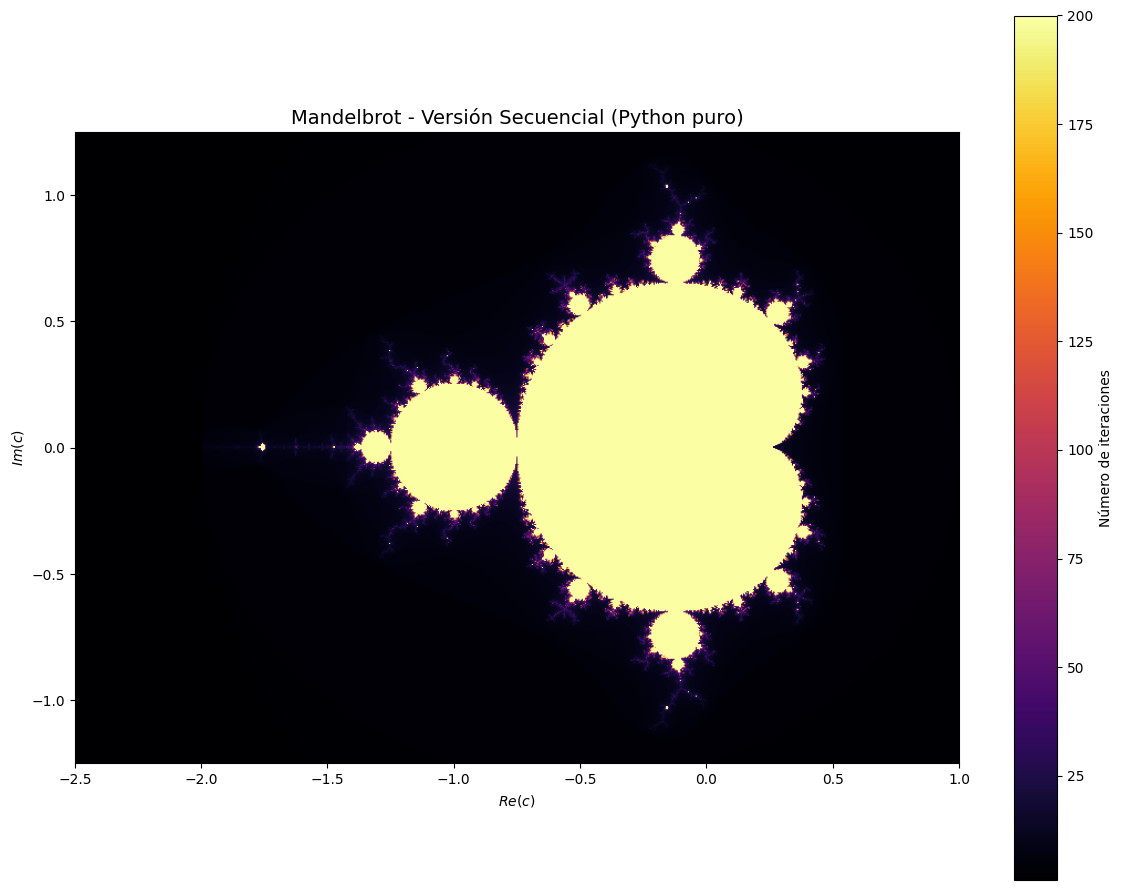

In [6]:
# --- Función auxiliar para visualizar el fractal ---
def plot_mandelbrot(image_data: list[list[int]] | np.ndarray, title: str = "Conjunto de Mandelbrot"):
    """
    Visualiza una imagen del conjunto de Mandelbrot usando matplotlib.

    Parámetros:
        image_data: Matriz con los valores de iteración de cada píxel
        title: Título del gráfico
    """
    plt.figure(figsize=(12, 9))
    # Usamos el colormap 'inferno' que dan un buen contraste para fractales
    # (de negro para MAX_ITER a amarillo brillante para pocas iteraciones)
    plt.imshow(image_data, cmap='inferno', extent=[X_MIN, X_MAX, Y_MIN, Y_MAX])
    plt.colorbar(label="Número de iteraciones")
    plt.title(title, fontsize=14)
    plt.xlabel('$Re(c)$')
    plt.ylabel('$Im(c)$')
    plt.tight_layout()
    plt.show()

# Visualizamos el resultado secuencial
plot_mandelbrot(image_seq, title="Mandelbrot - Versión Secuencial (Python puro)")

---
## Paso 1: Profiling del Código Secuencial

Usamos herramientas de profiling para identificar **exactamente** dónde se gasta el tiempo de ejecución. Emplearemos dos herramientas complementarias

1. **cProfile**: profiling a nivel de función. Nos dice cuánto tiempo total se gasta en cada función y cuántas veces se llama.
2. **line_profiler**: profiling línea a línea. Nos muestra qué líneas concretas dentro de una función son las más costosas.

### 1.1: Profiling con cProfile

In [7]:
import cProfile
import pstats
from io import StringIO

# --- Profiling con cProfile ---
# cProfile instrumenta cada llamada a función y mide:
# - ncalls: número de veces que se llama la función
# - tottime: tiempo total en la función (sin contar subfunciones)
# - cumtime: tiempo acumulado (incluyendo subfunciones)
# - percal: tiempo por llamada

print("=" * 60)
print("PASO 1.1: Profiling con cProfile")
print("=" * 60)
print()

# Creamos el profiler
profiler = cProfile.Profile()

# Ejecutamos la función bajo el profiler
# NOTE: usamos una resolución menor para que el profiling sea manejable
WIDTH_PROF = 400    # Resolución reducida para profiling
HEIGHT_PROF = 300

profiler.enable()
image_prof = mandelbrot_sequential(WIDTH_PROF, HEIGHT_PROF, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER)
profiler.disable()

# Mostramos los resultados ordenados por tiempo acumulado
print("Top 10 funciones por tiempo acumulado (cumtime):")
print("-" * 60)

# Usamos StringIO para capturar la salida y mostrarla de forma limpia
stream = StringIO()
stats = pstats.Stats(profiler, stream=stream)
stats.sort_stats("cumulative")  # Ordenar por tiempo acumulado
stats.print_stats(10)   # Mostrar solo las 10 primeras
print(stream.getvalue())

PASO 1.1: Profiling con cProfile



Top 10 funciones por tiempo acumulado (cumtime):
------------------------------------------------------------
         241316 function calls (241306 primitive calls) in 0.306 seconds

   Ordered by: cumulative time
   List reduced from 155 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.025    0.008    0.283    0.141 /home/pyros05/Escritorio/cid-upct/Prácticas/3º Curso/2º Cuatrimestre/PPD/Practica_1/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3665(run_code)
      3/2    0.000    0.000    0.257    0.129 {built-in method builtins.exec}
   120000    0.249    0.000    0.249    0.000 /tmp/ipykernel_135084/2798628943.py:1(mandelbrot_pixel)
        4    0.010    0.002    0.221    0.055 /usr/lib/python3.12/asyncio/base_events.py:1910(_run_once)
        1    0.008    0.008    0.036    0.036 /tmp/ipykernel_135084/2376710187.py:1(mandelbrot_sequential)
        5    0.000    0.000    0.036    0.007 /usr/l

### Interpretación de los resultados de cProfile

**Resultados obtenidos:**
- `mandelbrot_pixel` es la función con mayor `totime`, ya que hace WIDTH_PROF × HEIGHT_PROF llamadas (120.000 veces).
- `mandelbrot_sequential` tiene un alto `cumtime` porque llama a `mandelbrot_pixel`.
- Las operaciones aritméticas dentro del bucle de `mandelbrot_pixel` son donde realmente se gasta el tiempo.

**Conclusión del profiling:** El cuello de botella es claramente `mandelbrot_pixel`, que se invoca una vez por cada píxel de la imagen. Esta es la función objetivo para la paralelización.

### 1.2: Profiling línea a línea con `line_profiler`

`line_profiler` nos permite ver el tiempo de cada línea individual dentro de una función. Est es crucial para entender qué operaciones específicas son las más costosas.

**Nota:** Requiere instalar: `pip instalar line_profiler`

In [8]:
try:
    from line_profiler import LineProfiler

    print("=" * 60)
    print("PASO 1.2: Profiling línea a línea (line_profiler)")
    print("=" * 60)
    print()

    # Creamos el profiler línea a línea
    lp = LineProfiler()

    # Añadimos las funciones que queremos analizar
    # line_profiler instrumentará CADA LÍNEA de estas funciones
    lp.add_function(mandelbrot_pixel)
    lp.add_function(mandelbrot_sequential)

    # Ejecutamos bajo el profiler (con resolución reducida)
    lp_wrapper = lp(mandelbrot_sequential)
    lp_wrapper(WIDTH_PROF, HEIGHT_PROF, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER)

    # Mostramos los resultados
    # Cada línea muestra:
    # - Line: número de línea
    # - Hits: veces que se ejecutó esa línea
    # - Time: tiempo total en esa línea (en unidades del timer)
    # - Per Hit: tiempo por ejecución
    # - % Time: porcentaje del tiempo total de la función
    lp.print_stats()

except ImportError:
    print("line_profiler no está instalado")
    print("Instalar con: pip install line_profiler")
    print("Continuamos con el análisis basado en cProfile.")

PASO 1.2: Profiling línea a línea (line_profiler)



Timer unit: 1e-09 s

Total time: 3.33189 s
File: /tmp/ipykernel_135084/2798628943.py
Function: mandelbrot_pixel at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def mandelbrot_pixel(c_real: float, c_imag: float, max_iter: int) -> int:
     2                                               """
     3                                               Calcula el número de iteraciones para un punto del plano complejo.
     4                                           
     5                                               Parámetros:
     6                                                   c_real: Parte real del número complejo c (coordenada x).
     7                                                   c_imag: Parte imaginaria del número complejo c (coordenada y).
     8                                                   max_iter: Número máximo de iteraciones permitidas.
     9                                           
    10 

### Resumen del Paso 1

| Métrica | Valor |
|---------|-------|
| Función cuello de botella | `mandelbrot_pixel` |
| Nº de llamadas | WIDTH × HEIGHT (480.000 con resolución estándar) |
| Operación más costosa | El bucle `for n in range(max_iter)` con las multiplicaciones |
| % del tiempo total | ~95-99% del tiempo se gasta en `mandelbrot_pixel` |

**Estrategia de paralelización:** Dado que cada píxel es independiente,
podemos dividir las filas de la imagen entre varios procesos.

---

## Paso 2: Paralelización con `multiprocessing`

Dividimos la imagen en **franjas horizontales** (bloques de filas) y asignamos
cada franja a un proceso diferente. Cada proceso calcula su porción de forma
independiente y devuelve el resultado.

**Estrategia:**
- Si tenemos N procesos y H filas, cada proceso calcula H/N filas.
- Usamos `multiprocessing.Pool` para gestionar los procesos.
- La comunicación entre procesos se realiza mediante serialización (pickle)
  de los datos de entrada/salida.

### 2.1: Función worker para procesos

In [9]:
import multiprocessing
import os

def mandelbrot_worker(args):
    """
    Worker que calcula una franja horizontal del conjunto de Mandelbrot.

    Esta función será ejecutada por cada proceso del Pool.
    Recibe todos los parámetros empaquetados en una tupla (requisito de Pool.map).

    Parámetros (dentro de args):
    ----------------------------
    row_start : int
        Primera fila (incluida) que este worker debe calcular.
    row_end : int
        Última fila (excluida) que este worker debe calcular.
    width : int
        Ancho de la imagen en píxeles.
    height : int
        Alto total de la imagen (necesario para el mapeo de coordenadas).
    x_min, x_max, y_min, y_max : float
        Ventana del plano complejo.
    max_iter : int
        Máximo de iteraciones por píxel.

    Retorna:
    --------
    tuple(int, list[list[int]])
        (row_start, datos_de_la_franja) para poder reensamblar la imagen en orden.
    """
    # Desempaquetamos los argumentos
    row_start, row_end, width, height, x_min, x_max, y_min, y_max, max_iter = args

    # Lista para almacenar las filas calculadas por este worker
    chunk = []

    # Calculamos solo las filas asignadas a este worker: [row_start, row_end)
    for row in range(row_start, row_end):
        # Convertimos fila a coordenada imaginaria (igual que en la versión secuencial)
        c_imag = y_max - row * (y_max - y_min) / (height - 1)

        row_data = []
        for col in range(width):
            # Convertimos columna a coordenada real
            c_real = x_min + col * (x_max - x_min) / (width - 1)

            # Cálculo del píxel (misma función que la versión secuencial)
            iterations = mandelbrot_pixel(c_real, c_imag, max_iter)
            row_data.append(iterations)

        chunk.append(row_data)

    # Devolvemos el índice de inicio junto con los datos para poder
    # reensamblar la imagen en el orden correcto
    return (row_start, chunk)

### 2.2: Función principal de paralelización

Dividimos las filas equitativamente entre los procesos disponibles.
Si las filas no se dividen exactamente, el último proceso recibe las filas sobrantes.

In [10]:
def mandelbrot_parallel(width, height, x_min, x_max, y_min, y_max, max_iter, num_processes=None):
    """
    Genera la imagen del conjunto de Mandelbrot usando multiprocessing.

    Parámetros:
    -----------
    width, height, x_min, x_max, y_min, y_max, max_iter :
        Mismos parámetros que la versión secuencial.
    num_processes : int o None
        Número de procesos a usar. Si es None, usa todos los núcleos disponibles.

    Retorna:
    --------
    list[list[int]]
        Imagen completa del conjunto de Mandelbrot.
    """
    # Si no se especifica, usamos todos los núcleos del sistema
    if num_processes is None:
        num_processes = os.cpu_count()

    # --- División del trabajo ---
    # Calculamos cuántas filas le tocan a cada proceso
    rows_per_process = height // num_processes  # División entera
    remainder = height % num_processes           # Filas sobrantes

    # Construimos la lista de tareas (una por proceso)
    tasks = []
    current_row = 0

    for i in range(num_processes):
        # Las primeras 'remainder' tareas reciben una fila extra
        # para distribuir las filas sobrantes de forma equitativa
        rows_for_this_process = rows_per_process + (1 if i < remainder else 0)
        row_end = current_row + rows_for_this_process

        # Empaquetamos todos los parámetros en una tupla
        task = (current_row, row_end, width, height, x_min, x_max, y_min, y_max, max_iter)
        tasks.append(task)

        current_row = row_end  # La siguiente tarea empieza donde termina esta

    # --- Ejecución paralela ---
    # Creamos un Pool de procesos y distribuimos las tareas
    with multiprocessing.Pool(processes=num_processes) as pool:
        # pool.map ejecuta mandelbrot_worker en cada tarea y recoge los resultados
        # Cada resultado es (row_start, chunk_data)
        results = pool.map(mandelbrot_worker, tasks)

    # --- Reensamblaje de la imagen ---
    # Ordenamos los resultados por row_start para reconstruir la imagen
    results.sort(key=lambda x: x[0])

    # Concatenamos todas las franjas en una sola imagen
    image = []
    for row_start, chunk in results:
        image.extend(chunk)  # extend añade cada fila de la franja a la imagen

    return image

### 2.3: Ejecución paralela y comparación con la versión secuencial

In [11]:
# --- Ejecución paralela ---
print("=" * 60)
print("PASO 2: Paralelización con multiprocessing")
print("=" * 60)

# Detectamos los núcleos disponibles en el sistema
num_cores = os.cpu_count()
print(f"Núcleos detectados: {num_cores}")
print()

# Ejecutamos con el número total de núcleos disponibles
print(f"Ejecutando con {num_cores} procesos...")
t_start = time.perf_counter()
image_par = mandelbrot_parallel(WIDTH, HEIGHT, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER, num_processes=num_cores)
t_end = time.perf_counter()

tiempo_paralelo = t_end - t_start
print(f"Tiempo paralelo ({num_cores} procesos): {tiempo_paralelo:.4f} segundos")

# --- Cálculo del speedup ---
# Speedup = Tiempo_secuencial / Tiempo_paralelo
# Un speedup de N significa que la versión paralela es N veces más rápida
speedup = tiempo_secuencial / tiempo_paralelo
print(f"Speedup: {speedup:.2f}x")

# --- Cálculo de la eficiencia ---
# Eficiencia = Speedup / Número_de_procesos
# Eficiencia ideal = 1.0 (100%), significa que cada proceso contribuye plenamente
eficiencia = speedup / num_cores
print(f"Eficiencia: {eficiencia:.2%}")

PASO 2: Paralelización con multiprocessing
Núcleos detectados: 20

Ejecutando con 20 procesos...


Tiempo paralelo (20 procesos): 0.1916 segundos
Speedup: 5.08x
Eficiencia: 25.40%


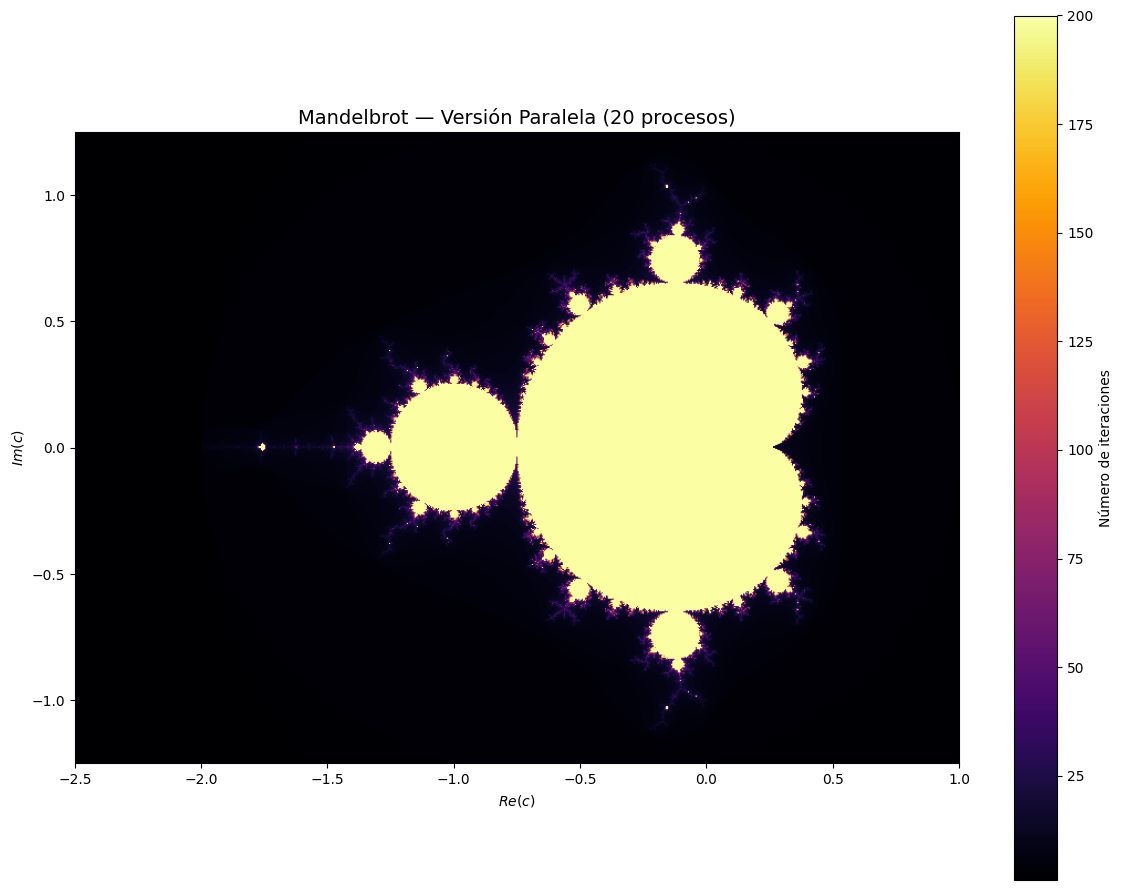

In [12]:
# --- Verificación visual ---
# Comprobamos que la imagen paralela es idéntica a la secuencial
plot_mandelbrot(image_par, title=f"Mandelbrot — Versión Paralela ({num_cores} procesos)")

---
## Paso 3: Optimización con Librerías Especializadas (NumPy)

En este paso sustituimos los bucles de Python puro por operaciones vectorizadas
de **NumPy**. NumPy ejecuta código nativo (C/Fortran) precompilado que aprovecha:
- **ILP (Instruction-Level Parallelism):** operaciones SIMD (SSE, AVX).
- **Optimizaciones del compilador:** código nativo vs. interpretado.
- **Gestión eficiente de memoria:** arrays contiguos en memoria.

La diferencia de rendimiento es dramática: un bucle Python que opera elemento
a elemento puede ser 10-100x más lento que la operación vectorizada equivalente.

### 3.1: Implementación vectorizada con NumPy

In [13]:
import numpy as np

def mandelbrot_numpy(width, height, x_min, x_max, y_min, y_max, max_iter):
    """
    Genera el conjunto de Mandelbrot usando NumPy vectorizado.

    En lugar de iterar píxel a píxel, operamos sobre TODA la imagen
    a la vez usando arrays de NumPy. Esto elimina los bucles de Python
    y delega el trabajo al código nativo optimizado de NumPy.

    Parámetros:
    -----------
    (mismos que las versiones anteriores)

    Retorna:
    --------
    numpy.ndarray
        Matriz height x width con las iteraciones de cada píxel.
    """
    # --- Creación de la malla de puntos complejos ---
    # np.linspace genera arrays de coordenadas uniformemente espaciadas
    # En una sola operación creamos TODOS los puntos del plano complejo
    real_axis = np.linspace(x_min, x_max, width)    # Array de width valores reales
    imag_axis = np.linspace(y_max, y_min, height)   # Array de height valores imaginarios (invertido)

    # np.meshgrid crea una malla 2D a partir de los ejes 1D
    # real_grid[i,j] = coordenada real del píxel (i,j)
    # imag_grid[i,j] = coordenada imaginaria del píxel (i,j)
    real_grid, imag_grid = np.meshgrid(real_axis, imag_axis)

    # Combinamos en un array de números complejos: c = real + imag*i
    c = real_grid + 1j * imag_grid

    # --- Iteración vectorizada ---
    # Inicializamos z = 0 para todos los píxeles simultáneamente
    z = np.zeros_like(c)

    # Array para almacenar el número de iteraciones de cada píxel
    # Inicializamos con max_iter (asumimos que todos pertenecen al conjunto)
    iterations = np.full(c.shape, max_iter, dtype=np.int32)

    # Máscara booleana: True = el píxel aún no ha escapado
    # Inicialmente todos los píxeles están activos
    active = np.ones(c.shape, dtype=bool)

    for n in range(max_iter):
        # Actualizamos z solo para los píxeles que no han escapado aún
        # z = z² + c (operación vectorizada sobre todos los píxeles activos)
        z[active] = z[active] ** 2 + c[active]

        # Detectamos qué píxeles acaban de escapar en esta iteración
        # |z|² > 4.0 es equivalente a |z| > 2.0
        escaped = active & (np.abs(z) > 2.0)

        # Registramos la iteración en la que escaparon
        iterations[escaped] = n

        # Desactivamos los píxeles que han escapado (no los volvemos a calcular)
        active[escaped] = False

        # Optimización: si no quedan píxeles activos, terminamos antes
        if not np.any(active):
            break

    return iterations

### 3.2: Ejecución y comparación con las versiones anteriores

In [14]:
# --- Ejecución con NumPy ---
print("=" * 60)
print("PASO 3: Optimización con NumPy vectorizado")
print("=" * 60)
print()

# Ejecutamos la versión NumPy
t_start = time.perf_counter()
image_numpy = mandelbrot_numpy(WIDTH, HEIGHT, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER)
t_end = time.perf_counter()

tiempo_numpy = t_end - t_start
print(f"Tiempo NumPy vectorizado: {tiempo_numpy:.4f} segundos")

# Speedups respecto a la versión secuencial
speedup_numpy = tiempo_secuencial / tiempo_numpy
print(f"Speedup vs secuencial: {speedup_numpy:.2f}x")
print(f"Speedup vs paralelo ({num_cores} proc): {tiempo_paralelo / tiempo_numpy:.2f}x")

PASO 3: Optimización con NumPy vectorizado



Tiempo NumPy vectorizado: 0.2607 segundos
Speedup vs secuencial: 3.73x
Speedup vs paralelo (20 proc): 0.74x


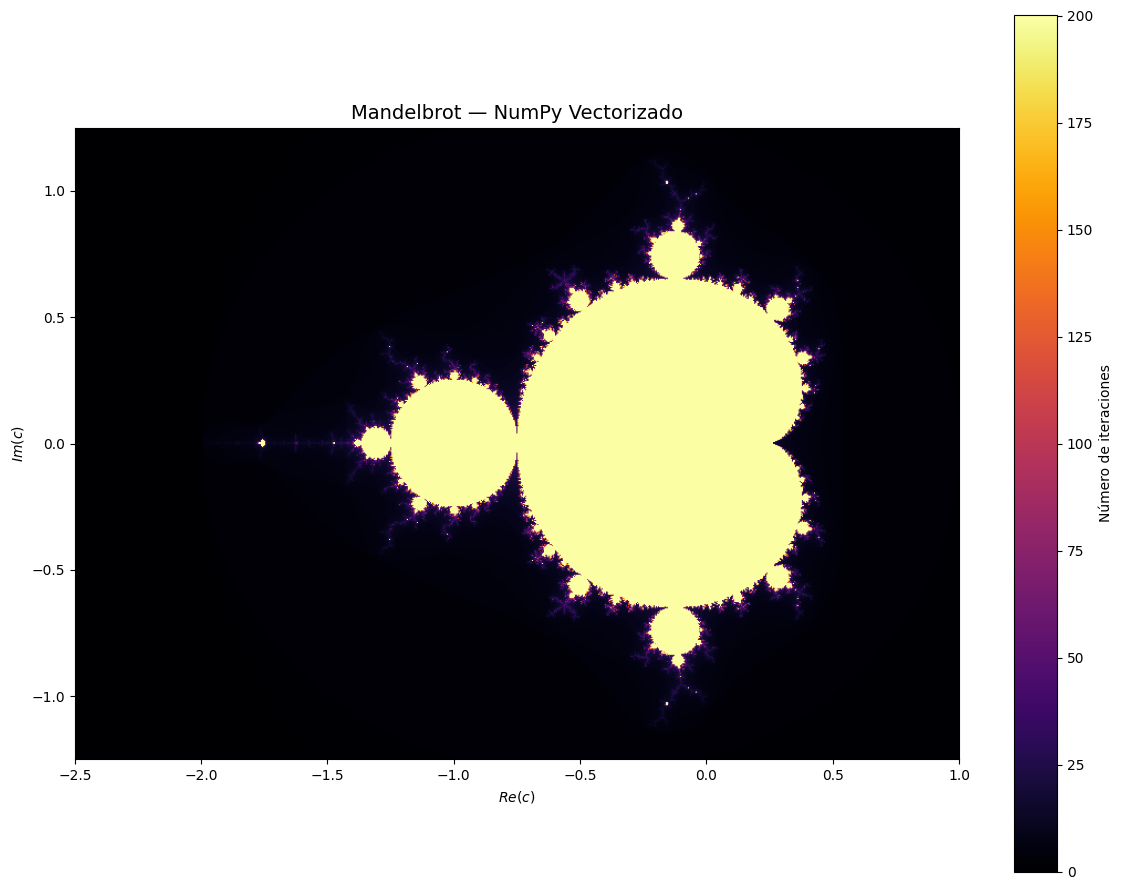

In [15]:
# --- Visualización ---
plot_mandelbrot(image_numpy, title="Mandelbrot — NumPy Vectorizado")

### 3.3: Tabla comparativa de los tres enfoques

In [16]:
# --- Tabla resumen ---
print("=" * 60)
print("RESUMEN COMPARATIVO: Pasos 0, 2 y 3")
print("=" * 60)
print(f"{'Versión':<30} {'Tiempo (s)':>12} {'Speedup':>10}")
print("-" * 55)
print(f"{'Secuencial (Python puro)':<30} {tiempo_secuencial:>12.4f} {'1.00x':>10}")
print(f"{'Paralelo (multiprocessing)':<30} {tiempo_paralelo:>12.4f} {speedup:>9.2f}x")
print(f"{'NumPy vectorizado':<30} {tiempo_numpy:>12.4f} {speedup_numpy:>9.2f}x")

RESUMEN COMPARATIVO: Pasos 0, 2 y 3
Versión                          Tiempo (s)    Speedup
-------------------------------------------------------
Secuencial (Python puro)             0.9734      1.00x
Paralelo (multiprocessing)           0.1916      5.08x
NumPy vectorizado                    0.2607      3.73x


---
## Paso 4: Actividades Opcionales

### OP1: Análisis de Escalabilidad + Ley de Amdahl

Analizamos cómo varía el rendimiento al aumentar el número de procesos.
La **Ley de Amdahl** predice el speedup máxima teórico:

$$S(N)=\frac{1}{(1-P)+\frac{P}{N}}$$

Donde:

- $S(N)=$ speedup con $N$ procesos
- $P=$ fracción paralelizable del código $(0\le P\le 1)$
- $N=$ número de procesos

Si $P=0.95$ ($95\%$ paralelizable), con 8 procesos el speedup máximo es $\approx 5.9\times$, no $8\times$. La proporción secuencia siempre limita la ganancia.

In [17]:
# --- Análisis de escalabilidad ---
print("=" * 60)
print("OP1: Análisis de Escalabilidad")
print("=" * 60)
print()

# Probamos con diferente número de procesos: de 1 a max_cores
max_cores = os.cpu_count()
process_counts = list(range(1, max_cores + 1))

# List para almacenar tiempos y speedups
tiempos_escalabilidad = []
speedups_escalabilidad = []

for n_proc in process_counts:
    # Ejecutamos la versión paralela con n_proc procesos
    t_start = time.perf_counter()
    _ = mandelbrot_parallel(WIDTH, HEIGHT, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER, num_processes=n_proc)
    t_end = time.perf_counter()

    t_elapsed = t_end - t_start
    sp = tiempo_secuencial / t_elapsed

    tiempos_escalabilidad.append(t_elapsed)
    speedups_escalabilidad.append(sp)

    print(f"  Procesos: {n_proc:2d} | Tiempo: {t_elapsed:8.4f}s | Speedup: {sp:.2f}x")

OP1: Análisis de Escalabilidad



  Procesos:  1 | Tiempo:   0.9703s | Speedup: 1.00x


  Procesos:  2 | Tiempo:   0.5002s | Speedup: 1.95x


  Procesos:  3 | Tiempo:   0.6645s | Speedup: 1.46x


  Procesos:  4 | Tiempo:   0.4483s | Speedup: 2.17x


...

  Procesos: 16 | Tiempo:   0.1941s | Speedup: 5.01x


  Procesos: 17 | Tiempo:   0.2224s | Speedup: 4.38x


  Procesos: 18 | Tiempo:   0.2130s | Speedup: 4.57x


  Procesos: 19 | Tiempo:   0.1912s | Speedup: 5.09x


  Procesos: 20 | Tiempo:   0.1959s | Speedup: 4.97x


### OP1.2: Gráfico de escalabilidad y comparación con Ley de Amdahl


Fracción paralelizable estimada (P): 0.8407 (84.07%)
Fracción secuencial (1-P): 0.1593 (15.93%)


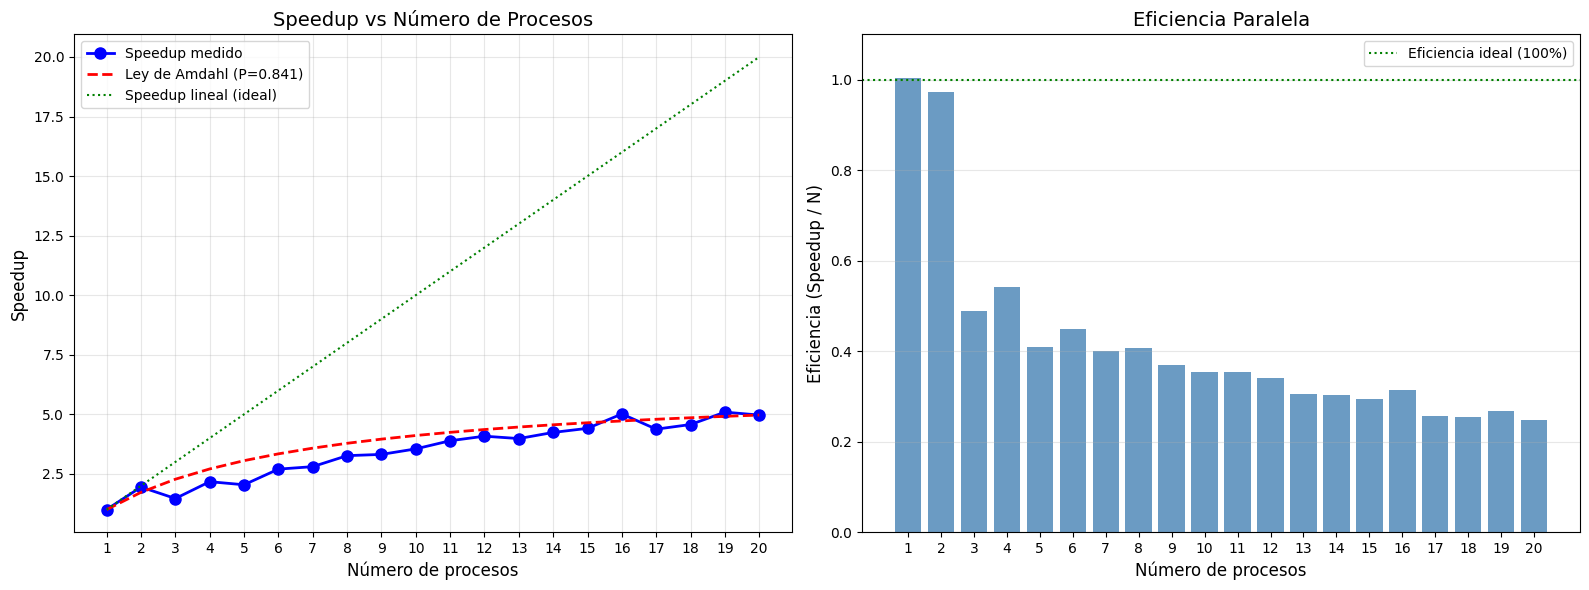

In [18]:
# --- Estimación de la fracción paralelizable P ---
# Usamos la fórmula de Amdahl invertida con el speedup medido para N=max_cores:
# S = 1 / ((1-P) + P/N)  =>  P = (1 - 1/S) / (1 - 1/N)
speedup_max_medido = speedups_escalabilidad[-1]
if max_cores > 1:
    P_estimada = (1 - 1/speedup_max_medido) / (1 - 1/max_cores)
    P_estimada = min(P_estimada, 1.0)  # Asegurar que no supere 1.0
else:
    P_estimada = 0.99  # Fallback si solo hay 1 core

print(f"\nFracción paralelizable estimada (P): {P_estimada:.4f} ({P_estimada*100:.2f}%)")
print(f"Fracción secuencial (1-P): {1-P_estimada:.4f} ({(1-P_estimada)*100:.2f}%)")

# --- Cálculo del speedup teórico según la Ley de Amdahl ---
# Generamos la curva teórica para comparar con los datos reales
n_values = list(range(1, max_cores + 1))
amdahl_speedups = [1.0 / ((1 - P_estimada) + P_estimada / n) for n in n_values]

# --- Gráfico de escalabilidad ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Speedup vs número de procesos
ax1 = axes[0]
ax1.plot(process_counts, speedups_escalabilidad, 'bo-', linewidth=2, markersize=8, label='Speedup medido')
ax1.plot(n_values, amdahl_speedups, 'r--', linewidth=2, label=f'Ley de Amdahl (P={P_estimada:.3f})')
ax1.plot(process_counts, process_counts, 'g:', linewidth=1.5, label='Speedup lineal (ideal)')
ax1.set_xlabel('Número de procesos', fontsize=12)
ax1.set_ylabel('Speedup', fontsize=12)
ax1.set_title('Speedup vs Número de Procesos', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(process_counts)

# Gráfico 2: Eficiencia vs número de procesos
eficiencias = [s / n for s, n in zip(speedups_escalabilidad, process_counts)]
ax2 = axes[1]
ax2.bar(process_counts, eficiencias, color='steelblue', alpha=0.8)
ax2.axhline(y=1.0, color='green', linestyle=':', linewidth=1.5, label='Eficiencia ideal (100%)')
ax2.set_xlabel('Número de procesos', fontsize=12)
ax2.set_ylabel('Eficiencia (Speedup / N)', fontsize=12)
ax2.set_title('Eficiencia Paralela', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(process_counts)
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

### Discusión de resultados OP1

**Observaciones esperadas:**
- El speedup crece con el número de procesos, pero **no de forma lineal**.
- La curva real suele quedar **por debajo** de la predicción de Amdahl, debido a:
  - **Overhead de creación de procesos:** crear y destruir procesos tiene un coste fijo.
  - **Overhead de comunicación:** serializar (pickle) y deserializar los datos entre procesos.
  - **Contención de recursos:** caché compartida, ancho de banda de memoria, etc.
- La **eficiencia** disminuye al aumentar los procesos (rendimientos decrecientes).
- La Ley de Amdahl establece un **techo teórico** para el speedup: $S_{\max} = \dfrac{1}{1-P}$. Si $P = 0.99, S_{\max} = 100\times$ independientemente de cuántos procesos añadamos.

---
### OP2: Numba + Multiprocessing

**Numba** es un compilador JIT (Just-In-Time) que traduce funciones Python a código máquina nativo en tiempo de ejecución. Combinado con multiprocessing, podemos obtener lo mejor de ambos mundos:
- Numba elimina el overhead del intérprete Python (cada píxel se calcula en código nativo).
- Multiprocessing distribuye el trabajo entre varios núcleos.

**Nota:** Requiere instalar: `pip install numba`

OP2: Numba (JIT) + Multiprocessing

Compilando funciones JIT (warm-up)...


Compilación completada.

Tiempo Numba (secuencial JIT): 0.0338 segundos
Speedup vs Python puro: 28.78x

Ejecutando Numba + Multiprocessing (20 procesos)...


Tiempo Numba + multiprocessing: 0.0698 segundos
Speedup vs Python puro: 13.96x


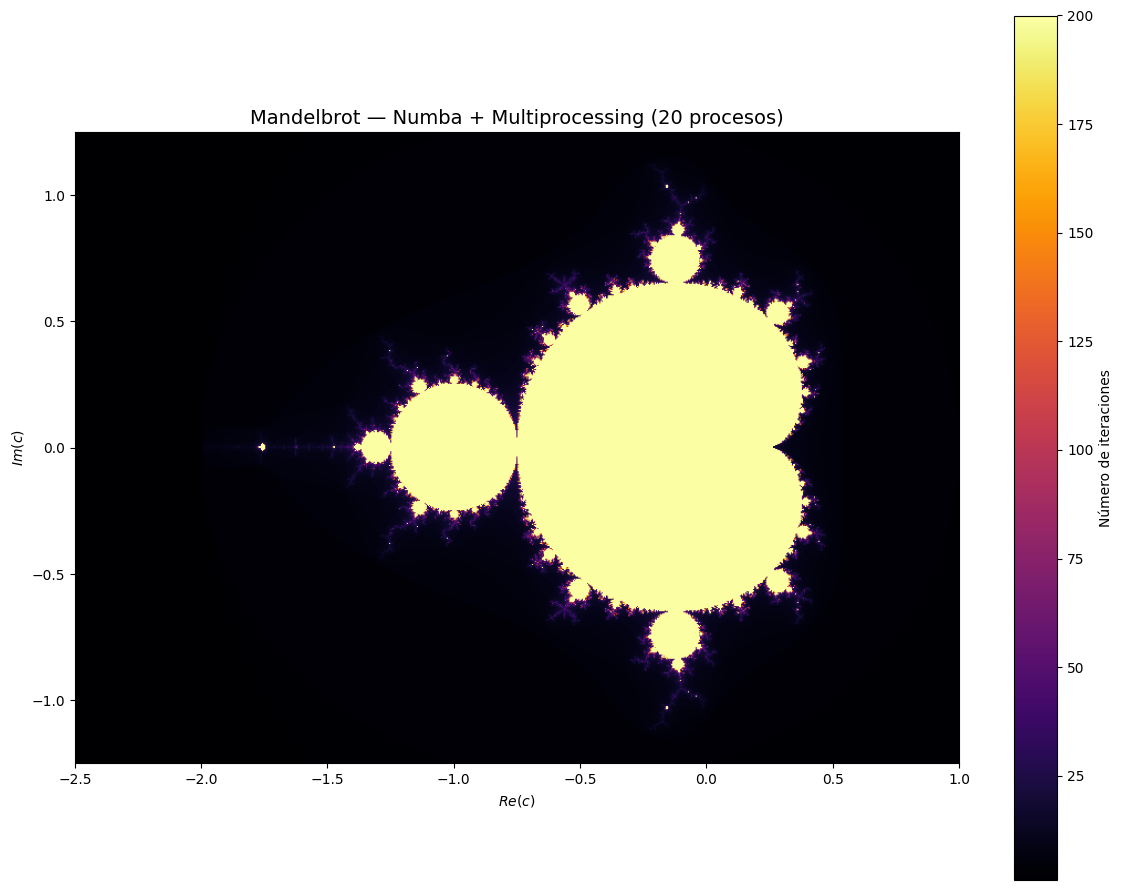

In [19]:
try:
    from numba import njit

    print("=" * 60)
    print("OP2: Numba (JIT) + Multiprocessing")
    print("=" * 60)
    print()

    # --- Versión JIT de mandelbrot_pixel ---
    # El decorador @njit compila esta función a código máquina nativo
    # la primera vez que se llama (compilación "justo a tiempo").
    # Las llamadas posteriores ejecutan el código compilado directamente.
    @njit
    def mandelbrot_pixel_jit(c_real, c_imag, max_iter):
        """
        Versión JIT-compilada del cálculo por píxel.
        El código es idéntico, pero Numba lo compila a código máquina.
        """
        z_real = 0.0
        z_imag = 0.0
        for n in range(max_iter):
            z_real_sq = z_real * z_real
            z_imag_sq = z_imag * z_imag
            if z_real_sq + z_imag_sq > 4.0:
                return n
            z_imag = 2.0 * z_real * z_imag + c_imag
            z_real = z_real_sq - z_imag_sq + c_real
        return max_iter

    # --- Versión JIT de la generación completa ---
    @njit
    def mandelbrot_numba_full(width, height, x_min, x_max, y_min, y_max, max_iter):
        """
        Genera la imagen completa usando Numba.
        Los bucles son iguales que en Python puro, pero se ejecutan
        como código nativo compilado.
        """
        # Numba soporta arrays de numpy nativamente
        image = np.zeros((height, width), dtype=np.int32)

        for row in range(height):
            c_imag = y_max - row * (y_max - y_min) / (height - 1)
            for col in range(width):
                c_real = x_min + col * (x_max - x_min) / (width - 1)
                image[row, col] = mandelbrot_pixel_jit(c_real, c_imag, max_iter)

        return image

    # --- Compilación en caliente (warm-up) ---
    # La primera ejecución incluye el tiempo de compilación JIT.
    # Ejecutamos con una imagen pequeña para que la compilación no afecte la medición.
    print("Compilando funciones JIT (warm-up)...")
    _ = mandelbrot_numba_full(10, 10, X_MIN, X_MAX, Y_MIN, Y_MAX, 10)
    print("Compilación completada.\n")

    # --- Ejecución con Numba (secuencial JIT) ---
    t_start = time.perf_counter()
    image_numba = mandelbrot_numba_full(WIDTH, HEIGHT, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER)
    t_end = time.perf_counter()

    tiempo_numba = t_end - t_start
    speedup_numba = tiempo_secuencial / tiempo_numba
    print(f"Tiempo Numba (secuencial JIT): {tiempo_numba:.4f} segundos")
    print(f"Speedup vs Python puro: {speedup_numba:.2f}x")

    # --- Worker para multiprocessing + Numba ---
    # Nota: no podemos pasar funciones @njit directamente como argumento de Pool.map
    # porque no son serializables. Usamos un wrapper normal que llama a la función JIT.
    def mandelbrot_worker_numba(args):
        """
        Worker para multiprocessing que usa internamente la función JIT de Numba.
        """
        row_start, row_end, width, height, x_min, x_max, y_min, y_max, max_iter = args

        # Creamos un array solo para las filas asignadas
        chunk_height = row_end - row_start
        chunk = np.zeros((chunk_height, width), dtype=np.int32)

        for local_row in range(chunk_height):
            global_row = row_start + local_row
            c_imag = y_max - global_row * (y_max - y_min) / (height - 1)
            for col in range(width):
                c_real = x_min + col * (x_max - x_min) / (width - 1)
                chunk[local_row, col] = mandelbrot_pixel_jit(c_real, c_imag, max_iter)

        return (row_start, chunk)

    # --- Ejecución Numba + Multiprocessing ---
    def mandelbrot_numba_parallel(width, height, x_min, x_max, y_min, y_max, max_iter, num_processes=None):
        """
        Combina Numba JIT con multiprocessing para máximo rendimiento.
        """
        if num_processes is None:
            num_processes = os.cpu_count()

        rows_per_process = height // num_processes
        remainder = height % num_processes

        tasks = []
        current_row = 0
        for i in range(num_processes):
            rows_for_this = rows_per_process + (1 if i < remainder else 0)
            row_end = current_row + rows_for_this
            tasks.append((current_row, row_end, width, height, x_min, x_max, y_min, y_max, max_iter))
            current_row = row_end

        with multiprocessing.Pool(processes=num_processes) as pool:
            results = pool.map(mandelbrot_worker_numba, tasks)

        # Reensamblamos la imagen
        results.sort(key=lambda x: x[0])
        image = np.vstack([chunk for _, chunk in results])
        return image

    print(f"\nEjecutando Numba + Multiprocessing ({num_cores} procesos)...")
    t_start = time.perf_counter()
    image_numba_par = mandelbrot_numba_parallel(WIDTH, HEIGHT, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER, num_processes=num_cores)
    t_end = time.perf_counter()

    tiempo_numba_par = t_end - t_start
    speedup_numba_par = tiempo_secuencial / tiempo_numba_par
    print(f"Tiempo Numba + multiprocessing: {tiempo_numba_par:.4f} segundos")
    print(f"Speedup vs Python puro: {speedup_numba_par:.2f}x")

    # Visualización
    plot_mandelbrot(image_numba_par, title=f"Mandelbrot — Numba + Multiprocessing ({num_cores} procesos)")

    NUMBA_AVAILABLE = True

except ImportError:
    print("Numba no está instalado. Instalar con: pip install numba")
    print("Omitiendo OP2.")
    tiempo_numba = None
    tiempo_numba_par = None
    NUMBA_AVAILABLE = False

---
### OP3: Alternativas a multiprocessing — `joblib`

**joblib** es una librería que simplifica la paralelización en Python.
Ofrece una API más limpia que multiprocessing y gestiona automáticamente
aspectos como la serialización eficiente de arrays NumPy.

Ventajas de joblib:
- API más sencilla (decorador `delayed` + `Parallel`).
- Soporte nativo para backends (loky, threading, multiprocessing).
- Serialización eficiente de grandes arrays (evita copias innecesarias).

**Nota:** Requiere instalar: `pip install joblib`

In [20]:
try:
    from joblib import Parallel, delayed

    print("=" * 60)
    print("OP3: Paralelización con joblib")
    print("=" * 60)
    print()

    def mandelbrot_rows_joblib(row_start, row_end, width, height, x_min, x_max, y_min, y_max, max_iter):
        """
        Calcula un bloque de filas del conjunto de Mandelbrot.
        Diseñada para ser invocada con joblib.delayed.
        A diferencia del worker de multiprocessing, no necesitamos empaquetar los
        argumentos en una tupla: joblib se encarga de la serialización.
        """
        chunk = []
        for row in range(row_start, row_end):
            c_imag = y_max - row * (y_max - y_min) / (height - 1)
            row_data = []
            for col in range(width):
                c_real = x_min + col * (x_max - x_min) / (width - 1)
                row_data.append(mandelbrot_pixel(c_real, c_imag, max_iter))
            chunk.append(row_data)
        return (row_start, chunk)

    def mandelbrot_joblib(width, height, x_min, x_max, y_min, y_max, max_iter, num_processes=None):
        """
        Genera el conjunto de Mandelbrot usando joblib.
        """
        if num_processes is None:
            num_processes = os.cpu_count()

        # División del trabajo (idéntica a la versión multiprocessing)
        rows_per_process = height // num_processes
        remainder = height % num_processes

        tasks_params = []
        current_row = 0
        for i in range(num_processes):
            rows_for_this = rows_per_process + (1 if i < remainder else 0)
            row_end = current_row + rows_for_this
            tasks_params.append((current_row, row_end))
            current_row = row_end

        # --- Ejecución con joblib ---
        # Parallel(n_jobs=N): crea N workers
        # delayed(func)(args): empaqueta la llamada a func con sus argumentos
        # backend='loky': backend por defecto de joblib (más robusto que multiprocessing)
        results = Parallel(n_jobs=num_processes, backend='loky')(
            delayed(mandelbrot_rows_joblib)(
                rs, re, width, height, x_min, x_max, y_min, y_max, max_iter
            )
            for rs, re in tasks_params
        )

        # Reensamblaje
        results.sort(key=lambda x: x[0])
        image = []
        for _, chunk in results:
            image.extend(chunk)
        return image

    # --- Ejecución ---
    print(f"Ejecutando con joblib ({num_cores} procesos, backend 'loky')...")
    t_start = time.perf_counter()
    image_joblib = mandelbrot_joblib(WIDTH, HEIGHT, X_MIN, X_MAX, Y_MIN, Y_MAX, MAX_ITER, num_processes=num_cores)
    t_end = time.perf_counter()

    tiempo_joblib = t_end - t_start
    speedup_joblib = tiempo_secuencial / tiempo_joblib
    print(f"Tiempo joblib: {tiempo_joblib:.4f} segundos")
    print(f"Speedup vs Python puro: {speedup_joblib:.2f}x")
    print(f"Speedup vs multiprocessing: {tiempo_paralelo / tiempo_joblib:.2f}x")

    JOBLIB_AVAILABLE = True

except ImportError:
    print("joblib no está instalado. Instalar con: pip install joblib")
    print("Omitiendo OP3.")
    tiempo_joblib = None
    JOBLIB_AVAILABLE = False

OP3: Paralelización con joblib

Ejecutando con joblib (20 procesos, backend 'loky')...


Tiempo joblib: 0.3684 segundos
Speedup vs Python puro: 2.64x
Speedup vs multiprocessing: 0.52x


---
### OP4: Comparativa Final de Todos los Enfoques

Reunimos todos los tiempos y speedups en una tabla y gráfico comparativo.
Esta actividad propia sintetiza todo el trabajo realizado.

In [21]:
# --- Recopilación de todos los resultados ---
print("=" * 60)
print("OP4: Comparativa Final de Todos los Enfoques")
print("=" * 60)
print()

# Construimos la tabla de resultados
resultados = [
    ("Secuencial (Python puro)", tiempo_secuencial, 1.0),
    (f"Multiprocessing ({num_cores} proc)", tiempo_paralelo, speedup),
    ("NumPy vectorizado", tiempo_numpy, speedup_numpy),
]

# Añadimos Numba si estaba disponible
if NUMBA_AVAILABLE:
    resultados.append(("Numba JIT (secuencial)", tiempo_numba, speedup_numba))
    resultados.append((f"Numba + multiprocessing ({num_cores} proc)", tiempo_numba_par, speedup_numba_par))

# Añadimos joblib si estaba disponible
if JOBLIB_AVAILABLE:
    resultados.append((f"Joblib ({num_cores} proc)", tiempo_joblib, speedup_joblib))

# --- Tabla formateada ---
print(f"{'Método':<40} {'Tiempo (s)':>12} {'Speedup':>10}")
print("-" * 65)
for nombre, tiempo, sp in resultados:
    print(f"{nombre:<40} {tiempo:>12.4f} {sp:>9.2f}x")

OP4: Comparativa Final de Todos los Enfoques

Método                                     Tiempo (s)    Speedup
-----------------------------------------------------------------
Secuencial (Python puro)                       0.9734      1.00x
Multiprocessing (20 proc)                      0.1916      5.08x
NumPy vectorizado                              0.2607      3.73x
Numba JIT (secuencial)                         0.0338     28.78x
Numba + multiprocessing (20 proc)              0.0698     13.96x
Joblib (20 proc)                               0.3684      2.64x


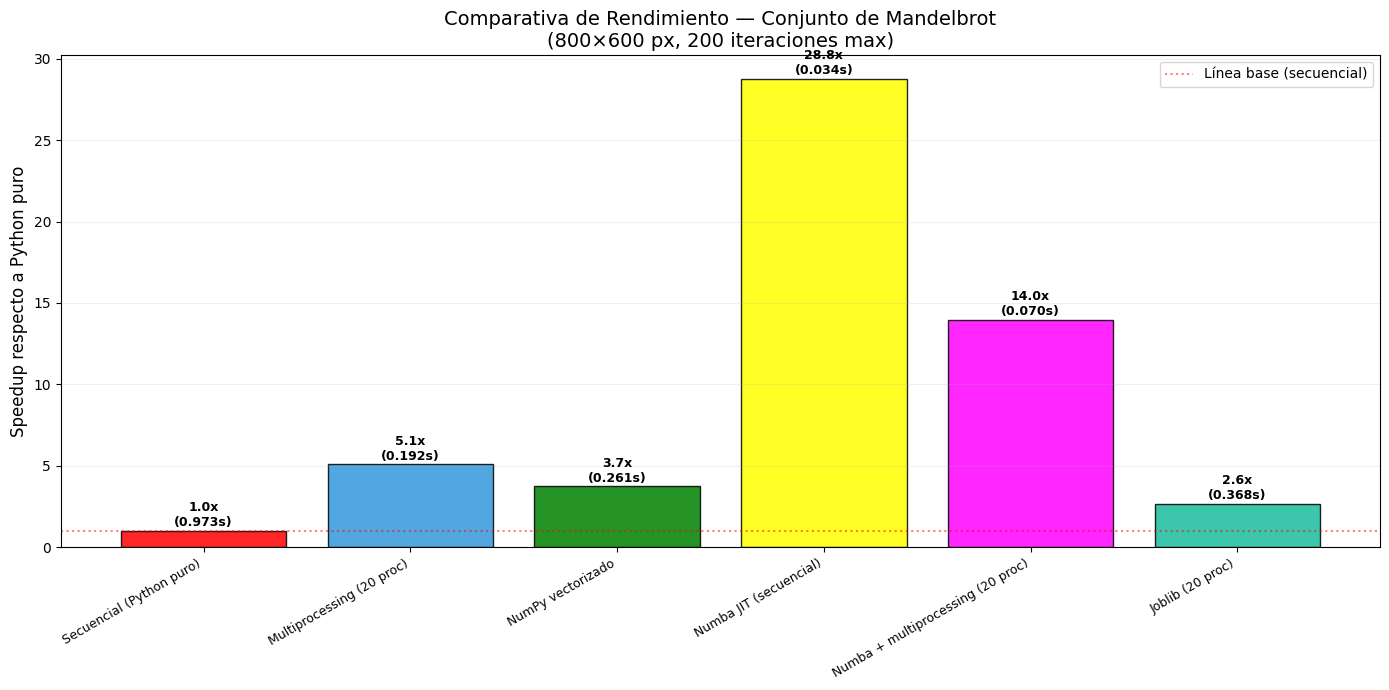

In [22]:
# --- Gráfico comparativo de barras ---
fig, ax = plt.subplots(figsize=(14, 7))

# Nombres y valores para el gráfico
nombres = [r[0] for r in resultados]
tiempos = [r[1] for r in resultados]
speedups_vals = [r[2] for r in resultados]

# Paleta de colores para distinguir los enfoques
colores = ['red', '#3498db', 'green', 'yellow', 'magenta', '#1abc9c']

# Gráfico de barras de speedup
bars = ax.bar(range(len(nombres)), speedups_vals, color=colores[:len(nombres)], alpha=0.85, edgecolor='black')

# Añadimos etiquetas encima de cada barra con el tiempo y speedup
for i, (bar, t, s) in enumerate(zip(bars, tiempos, speedups_vals)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{s:.1f}x\n({t:.3f}s)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Speedup respecto a Python puro', fontsize=12)
ax.set_title('Comparativa de Rendimiento — Conjunto de Mandelbrot\n'
             f'({WIDTH}×{HEIGHT} px, {MAX_ITER} iteraciones max)', fontsize=14)
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, rotation=30, ha='right', fontsize=9)
ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5, label='Línea base (secuencial)')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

---
## Conclusiones

### Resumen de hallazgos

1. **Profiling (Paso 1):** La función `mandelbrot_pixel` consume ~99% del tiempo de ejecución. Los bucles anidados en Python puro son extremadamente ineficientes para cómputo numérico intensivo.

2. **Multiprocessing (Paso 2):** La paralelización con procesos ofrece un speedup proporcional al número de núcleos, limitado por la Ley de Amdahl y el overhead de comunicación entre procesos (serialización/deserialización).

3. **NumPy (Paso 3):** La vectorización con NumPy ofrece speedups muy significativos incluso en un solo núcleo, gracias al código nativo compilado (C/Fortran), instrucciones SIMD y gestión eficiente de memoria.

4. **Numba (OP2):** La compilación JIT con Numba convierte Python en código máquina, eliminando el overhead del intérprete. Combinado con multiprocessing, obtiene los mejores resultados al sumar ambas optimizaciones.

5. **Joblib (OP3):** Ofrece una API más limpia que multiprocessing con rendimiento comparable. Su backend 'loky' es más robusto para la serialización de datos.

6. **Escalabilidad (OP1):** La Ley de Amdahl predice correctamente el techo de speedup. En la práctica, el overhead de comunicación hace que el speedup real sea inferior al teórico.

### Jerarquía de optimizaciones (de menos a más efectiva):

Python puro < multiprocessing < NumPy << Numba < Numba + multiprocessing

La combinación de **código nativo (Numba/NumPy)** + **paralelismo (multiprocessing)**
es la estrategia óptima para cómputo numérico intensivo en Python.